# Joint glitch + galactic binary inference in the WDM (time–frequency) domain

The frequency-domain counterpart of this analysis lives in `glitch_and_gb.ipynb`;
the injections, the noise model and the priors here are identical, so the two sets
of posteriors can be compared directly.

## The idea

In the Wilson–Daubechies–Meyer basis the two signals occupy almost disjoint sets of
pixels, and stationary noise is (nearly) diagonal. That suggests splitting the
likelihood into two pieces evaluated on **two different WDM tilings of the same data**:

| | grid | kept pixels | why |
|---|---|---|---|
| **Galactic binary** | fine frequency, coarse time (`Nf = 1536`, `Δt ≈ 3 d`) | a few channels around `f₀`, all time bins | quasi-monochromatic and always on |
| **Glitch** | coarse frequency, fine time (`Nf = 32`, `Δt ≈ 5333 s`) | a few time bins around `t₀`, all channels except a notch at `f₀` | a broadband burst, compact in time |

so that

$$\log\mathcal{L} \simeq \log\mathcal{L}_{\rm GB}\big(\theta_{\rm GB}\big)
  + \log\mathcal{L}_{\rm gl}\big(\theta_{\rm gl}\big).$$

Two things have to be checked rather than assumed, and both are done below:
**how much signal the windows retain**, and **how much each signal contaminates the
other's window**.

## Three practical points, established empirically before writing any of this

1. **The sample count must divide both tilings exactly.** With `N` not divisible by
   `Nt·Nf` one has to truncate the series, which breaks periodicity and sprays
   broadband leakage over the first time bins — exactly where the glitch window is.
   That leakage put the GB into the glitch window at SNR ≈ 5, versus **0.13** once
   `N = 187392` (divisible by 3072) makes both tilings exact.
2. **The glitch transform can be done on a short segment.** The WDM transform is local
   in time up to an overall $\sqrt{N}$ normalisation, and that factor cancels in the
   likelihood because the noise variance carries it too. Transforming 4096 samples
   instead of 187392 reproduces the windowed SNR to **0.05 %** and costs **1.4 ms**
   instead of 58 ms.
3. **The posterior factorises.** With disjoint likelihoods the GB block and the glitch
   block are formally independent, which is itself a prediction to check against the
   frequency-domain corner plot.

In [1]:
import sys, os, time
from pathlib import Path

# Repository root, found by walking up from the notebook's directory; noise.py
# lives in notebooks/, one level above this notebook.
REPO = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p / 'pyproject.toml').exists())
sys.path.insert(0, str(REPO / 'notebooks'))

# Allocate GPU memory on demand instead of grabbing 75% of the device up front.
# Must be set before JAX is imported. Without it a single kernel reserves ~6 GB of
# the 8 GB card, and anything else touching the GPU -- another notebook, a script --
# dies with CUDA_ERROR_OUT_OF_MEMORY on its first transform.
os.environ.setdefault('XLA_PYTHON_CLIENT_PREALLOCATE', 'false')

import jax
jax.config.update('jax_enable_x64', True)
import jax.numpy as jnp
import jax.random as jr
import numpy as np
import matplotlib.pyplot as plt

import lisaorbits
from jaxgb import jaxgb as jgb_mod

import jaxglitches as jg
import noise as ns

from wdm_transform import TimeSeries, WDM, wdm_noise_variance
from wdm_transform.backends import get_backend

from jexplore.sampler import JaxSampler, Steps
from jexplore.sampling import EpochMH, SamplingMH
from jexplore.steps import Stretch
from jexplore.backends import DefaultBackend

WDM_BACKEND = get_backend('jax')
print('JAX devices:', jax.devices())

/home/giorgio/Desktop/jaxglitches/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
/home/giorgio/Desktop/jaxglitches/.venv/lib/python3.12/site-packages/lisaconstants/compat/astropy.py:252: UserWarning: The following constants differ between lisaconstants and the version of astropy you have installed: VACUUM_PERMEABILITY. The recommended version of astropy is 7.2.0. Use a different one at your own risks. 
You may also open an issue at https://gitlab.esa.int/lisa-sgs/commons/lisa-constants to warn that lisaconstants is not compatible with astropy v8.0.1
  warnings.warn(


JAX devices: [CudaDevice(id=0)]


## 1. Observation, grids, noise

`N` is chosen divisible by 3072 so that **both** tilings divide it exactly:
`N/32 = 5856` and `N/1536 = 122`, both even, as the transform requires.

In [2]:
# ── Grid, read from the shared data set ──────────────────────────────────────
# `make_dataset.py` writes one data stream consumed by both this notebook and
# glitch_and_gb.ipynb, so the frequency-domain and time--frequency analyses see
# identical data: same grid, same injections, same noise draw. That is what lets
# their posterior *centres* be compared and not only their widths.
DS = np.load('dataset.npz')

DT       = float(DS['DT'])
N        = int(DS['N'])            # divisible by 3072: both tilings divide it exactly
T_OBS    = float(DS['T_OBS'])
T_ARM    = float(DS['T_ARM'])

F0_GUESS = float(DS['gb_true'][0])  # GB frequency, sets where the notch goes
NF_GB    = 1536                    # GB tiling: fine frequency, coarse time
NT_GB    = N // NF_GB              # = 122
NF_GL    = 128                     # glitch tiling: coarser frequency, finer time
NT_GL    = N // NF_GL              # = 1464

freq   = jnp.asarray(np.fft.rfftfreq(N, DT))
f_safe = jnp.where(freq > 0, freq, 1.0)
n_fine = len(freq)
df     = float(freq[1])

print(f'N = {N:,}   T_obs = {T_OBS:.4e} s = {T_OBS/86400:.2f} d   dt = {DT:.3f} s')
print(f'fine FD grid: {n_fine:,} bins, df = {df:.3e} Hz, f_max = {float(freq[-1]):.4e} Hz')
print(f'GB tiling    : Nf = {NF_GB}, Nt = {NT_GB}, dt_wdm = {NF_GB*DT/86400:.3f} d, '
      f'df_wdm = {(float(freq[-1])/NF_GB)*1e6:.3f} uHz')
print(f'glitch tiling: Nf = {NF_GL}, Nt = {NT_GL:,}, dt_wdm = {NF_GL*DT:.0f} s '
      f'({NF_GL*DT/3600:.2f} h), df_wdm = {(float(freq[-1])/NF_GL)*1e6:.2f} uHz')


N = 187,392   T_obs = 3.1232e+07 s = 361.48 d   dt = 166.667 s
fine FD grid: 93,697 bins, df = 3.202e-08 Hz, f_max = 3.0000e-03 Hz
GB tiling    : Nf = 1536, Nt = 122, dt_wdm = 2.963 d, df_wdm = 1.953 uHz
glitch tiling: Nf = 128, Nt = 1,464, dt_wdm = 21333 s (5.93 h), df_wdm = 23.44 uHz


## 2. Injections

Identical to `glitch_and_gb.ipynb`. The Galactic binary is a heavy double white dwarf
($\mathcal{M}=0.79\,M_\odot$, so the chirp is measurable over a year); the glitch has
its spectral knee $1/(2\pi\tau)$ inside the band, which is what makes $\tau$ (and
through it $t_0$) measurable at all.

In [3]:
gb_params_true     = jnp.asarray(DS['gb_true'])[None, :]
glitch_params_true = jnp.asarray(DS['glitch_true'])
(F0_TRUE, FDOT_TRUE, A_GB_TRUE, RA_TRUE,
 DEC_TRUE, PSI_TRUE, IOTA_TRUE, PHI0_TRUE) = [float(v) for v in DS['gb_true']]
T0_TRUE, DELTAV_TRUE, TAU_TRUE = [float(v) for v in DS['glitch_true']]
A_G_TRUE = DELTAV_TRUE * TAU_TRUE

N_GB = int(DS['N_GB'])
orbit = lisaorbits.EqualArmlengthOrbits()
jgb_model = jgb_mod.JaxGB(orbit, t_obs=float(T_OBS), t0=0.0, n=N_GB)
k_min_true = int(jgb_model.get_kmin(gb_params_true[:, 0])[0])

def gb_fd(gb8):
    """GB signal on the full fine FD grid, (n_fine, 3) complex."""
    p = gb8[None, :]
    segs = jgb_model.get_tdi(p, tdi_generation=1.5, tdi_combination='AET')
    seg = jnp.stack(segs, axis=0).astype(jnp.complex128)[:, 0, :].T      # (N_GB, 3)
    k = jgb_model.get_kmin(p[:, 0])[0].astype(jnp.int32)
    out = jnp.zeros((n_fine, 3), dtype=jnp.complex128)
    zero = jnp.zeros((), dtype=jnp.int32)          # both indices must share a dtype
    return jax.lax.dynamic_update_slice(out, seg, (k, zero))

def glitch_fd(g3):
    """Glitch TDI-1 signal on the full fine FD grid, (n_fine, 3) complex."""
    return jg.clean_signal_f(g3, freq, tdi=1).at[0].set(0 + 0j)

h_gb_fd     = gb_fd(gb_params_true[0])
h_glitch_fd = glitch_fd(glitch_params_true)

psd_bin = ns.psd_tdi1_array(f_safe, t_obs=T_OBS)      # per-bin variance, for FD checks
print(f'GB     : f0 = {F0_TRUE*1e3:.3f} mHz at bin {k_min_true:,}, '
      f'FD SNR = {float(jg.snr(h_gb_fd, psd_bin)):.2f}')
print(f'glitch : t0 = {T0_TRUE:.0f} s, tau = {TAU_TRUE:.0f} s, knee = '
      f'{1/(2*np.pi*TAU_TRUE)*1e3:.3f} mHz, FD SNR = '
      f'{float(jg.snr(h_glitch_fd, psd_bin)):.2f}')


GB     : f0 = 2.000 mHz at bin 62,336, FD SNR = 283.47
glitch : t0 = 400 s, tau = 300 s, knee = 0.531 mHz, FD SNR = 42.69


### Why both tilings run at full length

The obvious optimisation is to transform only a short segment around the glitch: the
WDM transform is local in time up to a $\sqrt{N}$ normalisation that cancels against
the noise variance, and a 4032-sample segment reproduces the windowed glitch SNR to
0.05 % at a fraction of the cost.

It does not work, for a reason worth recording. Cutting a short window out of a
year-long **red-noise** series leaves year-timescale wander inside it that the
segment's own diagonal noise model cannot describe. Whitened noise coefficients that
should have unit variance come out at

| segment | 7.8 d | 23.7 d | 45 d | 90 d | 181 d | full year |
|---|---|---|---|---|---|---|
| std | 1.81 | 3.08 | 3.29 | 4.13 | 5.80 | **0.997** |

and the mismodelling gets *worse* with segment length, because for $S\propto f^{-2}$
the variance below $1/T_{\rm seg}$ grows with $T_{\rm seg}$. Only the untruncated
series is self-consistent. Feeding the biased variances to the likelihood made the
fit absorb the excess noise into the glitch: $A_g$ came out a factor two high,
a $10\sigma$ bias.

The cost objection turns out to be soft anyway. The transform scales with the number
of time bins, not with $N$, so moving from $N_f=32$ ($N_t=5856$, 58 ms) to
$N_f=128$ ($N_t=1464$, **6.6 ms**) buys back the speed at full length. $\Delta t$ is
then 5.9 h, which still puts the entire 1667 s burst inside a single time bin.

## 3. The two WDM tilings

`wdm_noise_variance` wants the **one-sided physical PSD** $S_1(f)$ sampled at the
channel centres — not the per-bin variance used by the frequency-domain likelihood.
Its convention is $\sigma^2_{nm} = N\,S_1(f_m)/(2\Delta t)$, so both the coefficients
and their variance scale with $N$; that is why the segment normalisation cancels.

The DC and Nyquist channels are rank-deficient and come back as `NaN`; every sum below
skips them.

In [4]:
def to_time(H_fd, n=N):
    """Fine FD grid (n_fine, 3) -> real time series (3, n)."""
    return jnp.stack([jnp.fft.irfft(H_fd[:, c], n=n) / DT for c in range(3)])

def wdm_of(x, nt):
    """WDM coefficients of a (3, L) real series."""
    return WDM.from_time_series(TimeSeries(x, dt=DT, backend=WDM_BACKEND), nt=nt)

def pixel_variance(freq_grid, nt, nf):
    """Per-pixel noise variance, (3, nt, nf+1).

    `wdm_noise_variance` returns the full (nt, nf+1) grid -- the value depends only on
    the channel, but it is broadcast over time bins, and the DC/Nyquist columns come
    back as NaN so that they are skipped by every sum."""
    fch = jnp.where(jnp.asarray(freq_grid) > 0, jnp.asarray(freq_grid), 1.0)
    S1 = jnp.stack(ns.psd_tdi1(fch), axis=-1)                       # (nf+1, 3) one-sided
    return jnp.stack([jnp.asarray(wdm_noise_variance(np.asarray(S1[:, c]),
                                                     nt=nt, nf=nf, dt=DT))
                      for c in range(3)])

# reference grids, built once from the injected signals
_w = wdm_of(to_time(h_gb_fd), NT_GB)
FREQ_GB, TIME_GB = np.asarray(_w.freq_grid), np.asarray(_w.time_grid)
VAR_GB = pixel_variance(_w.freq_grid, NT_GB, NF_GB)                 # (3, NT_GB, NF_GB+1)

_w = wdm_of(to_time(h_glitch_fd), NT_GL)
FREQ_GL, TIME_GL = np.asarray(_w.freq_grid), np.asarray(_w.time_grid)
VAR_GL = pixel_variance(_w.freq_grid, NT_GL, NF_GL)                 # (3, NT_GL, NF_GL+1)

print(f'GB     grid: {NT_GB} x {NF_GB+1} pixels, df = {FREQ_GB[1]*1e6:.3f} uHz, '
      f'dt = {TIME_GB[1]/86400:.3f} d')
print(f'glitch grid: {NT_GL} x {NF_GL+1} pixels, df = {FREQ_GL[1]*1e6:.1f} uHz, '
      f'dt = {TIME_GL[1]:.0f} s')

def snr_wdm(coeffs, var, sl=None):
    """sqrt(sum w^2/sigma^2), skipping NaN edge channels."""
    r = coeffs ** 2 / var
    r = r if sl is None else r[sl]
    return float(jnp.sqrt(jnp.nansum(r)))

GB     grid: 122 x 1537 pixels, df = 1.953 uHz, dt = 2.963 d
glitch grid: 1464 x 129 pixels, df = 23.4 uHz, dt = 21333 s


## 4. Where the signals actually sit

The windows are not guessed: they follow from measuring how the signal-to-noise ratio
accumulates over pixels.

In [5]:
w_gb_full = wdm_of(to_time(h_gb_fd), NT_GB).coeffs                     # (3, NT_GB, NF_GB+1)
w_gl_full = wdm_of(to_time(h_glitch_fd), NT_GL).coeffs                # (3, NT_GL, NF_GL+1)

r_gb = np.asarray(jnp.nan_to_num(w_gb_full ** 2 / VAR_GB))
r_gl = np.asarray(jnp.nan_to_num(w_gl_full ** 2 / VAR_GL))

per_f_gb = r_gb.sum(axis=(0, 1))      # GB: how SNR^2 spreads over channels
per_t_gl = r_gl.sum(axis=(0, 2))      # glitch: how SNR^2 spreads over time bins
cum_f = np.cumsum(np.sort(per_f_gb)[::-1]) / per_f_gb.sum()
cum_t = np.cumsum(np.sort(per_t_gl)[::-1]) / per_t_gl.sum()

print(f'GB     total WDM SNR = {np.sqrt(r_gb.sum()):.2f}')
print(f'  brightest channel  : {FREQ_GB[per_f_gb.argmax()]*1e3:.4f} mHz '
      f'(f0 = {F0_TRUE*1e3:.3f} mHz)')
print(f'  SNR^2 in top 1/3/5 channels: {cum_f[0]:.4f} / {cum_f[2]:.4f} / {cum_f[4]:.4f}')
print(f'glitch total WDM SNR = {np.sqrt(r_gl.sum()):.2f}')
print(f'  brightest time bin : t = {TIME_GL[per_t_gl.argmax()]:.0f} s (t0 = {T0_TRUE:.0f} s)')
print(f'  SNR^2 in top 1/3/10 bins  : {cum_t[0]:.4f} / {cum_t[2]:.4f} / {cum_t[9]:.4f}')

GB     total WDM SNR = 283.47
  brightest channel  : 2.0000 mHz (f0 = 2.000 mHz)
  SNR^2 in top 1/3/5 channels: 1.0000 / 1.0000 / 1.0000
glitch total WDM SNR = 42.70
  brightest time bin : t = 0 s (t0 = 400 s)
  SNR^2 in top 1/3/10 bins  : 0.5944 / 0.9677 / 0.9984


In [6]:
# ── window definitions ───────────────────────────────────────────────────────
K_GB   = int(np.argmin(np.abs(FREQ_GB - F0_TRUE)))    # GB channel
HALF_F = 2                                            # +/- channels kept for the GB
GB_CH  = np.arange(max(1, K_GB - HALF_F), min(NF_GB, K_GB + HALF_F + 1))

NT_WIN   = 4                                          # time bins kept for the glitch
GL_T     = np.arange(NT_WIN)
K_GL_NOTCH = int(np.argmin(np.abs(FREQ_GL - F0_TRUE)))
HALF_N   = 1                                          # +/- channels notched out
GL_CH    = np.array([m for m in range(1, NF_GL)
                     if abs(m - K_GL_NOTCH) > HALF_N])

print(f'GB window    : channels {GB_CH[0]}..{GB_CH[-1]} '
      f'({FREQ_GB[GB_CH[0]]*1e3:.4f}..{FREQ_GB[GB_CH[-1]]*1e3:.4f} mHz) x {NT_GB} time bins'
      f'  = {len(GB_CH)*NT_GB:,} pixels')
print(f'glitch window: time bins 0..{NT_WIN-1} (t < {TIME_GL[NT_WIN-1]:.0f} s) x '
      f'{len(GL_CH)} channels (notching {2*HALF_N+1} around {FREQ_GL[K_GL_NOTCH]*1e3:.3f} mHz)'
      f'  = {len(GL_CH)*NT_WIN:,} pixels')

GB window    : channels 1022..1026 (1.9961..2.0039 mHz) x 122 time bins  = 610 pixels
glitch window: time bins 0..3 (t < 64000 s) x 124 channels (notching 3 around 1.992 mHz)  = 496 pixels


### Do the windows keep the signal, and do they keep the *other* signal out?

In [7]:
w_gl_of_gb = wdm_of(to_time(h_gb_fd), NT_GL).coeffs                # GB on the glitch grid
w_gb_of_gl = wdm_of(to_time(h_glitch_fd), NT_GB).coeffs            # glitch on the GB grid

def win_snr(coeffs, var, tsel, fsel):
    r = jnp.nan_to_num(coeffs ** 2 / var)
    return float(jnp.sqrt(jnp.sum(r[:, tsel][:, :, fsel])))

sn = {
    'GB in GB window'        : win_snr(w_gb_full,  VAR_GB, np.arange(NT_GB), GB_CH),
    'glitch in GB window'    : win_snr(w_gb_of_gl, VAR_GB, np.arange(NT_GB), GB_CH),
    'glitch in glitch window': win_snr(w_gl_full,  VAR_GL, GL_T, GL_CH),
    'GB in glitch window'    : win_snr(w_gl_of_gb, VAR_GL, GL_T, GL_CH),
}
print(f'{"":26s}   SNR')
for k, v in sn.items():
    print(f'  {k:24s} {v:8.3f}')
print(f'\nretained: GB {100*sn["GB in GB window"]/np.sqrt(r_gb.sum()):.1f}%, '
      f'glitch {100*sn["glitch in glitch window"]/np.sqrt(r_gl.sum()):.1f}%')
print(f'contamination: glitch leaks SNR {sn["glitch in GB window"]:.2f} into the GB window, '
      f'GB leaks SNR {sn["GB in glitch window"]:.2f} into the glitch window')

                             SNR
  GB in GB window           283.471
  glitch in GB window         0.666
  glitch in glitch window    38.430
  GB in glitch window         0.000

retained: GB 100.0%, glitch 90.0%
contamination: glitch leaks SNR 0.67 into the GB window, GB leaks SNR 0.00 into the glitch window


## 5. Data

The data stream comes from `dataset.npz` -- the same file `glitch_and_gb.ipynb` reads,
so the two analyses differ only in how they process identical numbers. It is mapped to
the time domain and transformed on **both** tilings; the two likelihood pieces must see
the same physical data, not two independent draws.


In [8]:
# ── Data, read from the shared data set ──────────────────────────────────────
data_fd = jnp.asarray(DS['data_tdi1'])
n_fd    = jnp.asarray(DS['noise_tdi1'])
x_data  = to_time(data_fd)

# the templates built here must reproduce the stored signals
for nm, stored, built in [('GB', DS['h_gb_tdi1'], h_gb_fd),
                          ('glitch', DS['h_glitch_tdi1'], h_glitch_fd)]:
    dev = float(jnp.max(jnp.abs(jnp.asarray(stored) - built)) / jnp.max(jnp.abs(built)))
    print(f'  {nm:7s} template vs stored: max relative deviation {dev:.2e}')

d_gb = wdm_of(x_data, NT_GB).coeffs                    # (3, NT_GB, NF_GB+1)
d_gl = wdm_of(x_data, NT_GL).coeffs                    # (3, NT_GL, NF_GL+1)

print(f'data on GB grid     : {tuple(d_gb.shape)}')
print(f'data on glitch grid : {tuple(d_gl.shape)}')
print(f'total FD SNR of the injected pair = '
      f'{float(jg.snr(h_gb_fd + h_glitch_fd, psd_bin)):.2f}')


  GB      template vs stored: max relative deviation 2.04e-16
  glitch  template vs stored: max relative deviation 0.00e+00
data on GB grid     : (3, 122, 1537)
data on glitch grid : (3, 1464, 129)
total FD SNR of the injected pair = 286.65


### Is the noise really white after whitening?

The diagonal-Whittle likelihood assumes the WDM coefficients of stationary noise are
independent with variance $\sigma^2_{nm}$. That is exact only if the PSD is flat across
a channel, which it is not — least of all on the `Nf = 128` tiling, where a
channel is 23 µHz wide. Worth checking rather than assuming.

In [9]:
w_n_gb = wdm_of(to_time(n_fd), NT_GB).coeffs
w_n_gl = wdm_of(to_time(n_fd), NT_GL).coeffs

for lbl, w, var, nfc in [('GB grid (Nf=1536)', w_n_gb, VAR_GB, NF_GB),
                         ('glitch grid (Nf=128)', w_n_gl, VAR_GL, NF_GL)]:
    z = np.asarray(w / jnp.sqrt(var))[:, :, 1:nfc]     # drop DC/Nyquist
    lag1 = np.mean(z[:, :-1, :] * z[:, 1:, :])                     # time-lag-1 correlation
    lagf = np.mean(z[:, :, :-1] * z[:, :, 1:])                     # channel-lag-1
    print(f'{lbl:22s} mean = {z.mean():+.4f}, std = {z.std():.4f}, '
          f'lag-1 in time = {lag1:+.4f}, in channel = {lagf:+.4f}')

GB grid (Nf=1536)      mean = +0.0021, std = 0.9997, lag-1 in time = +0.0013, in channel = +0.0013
glitch grid (Nf=128)   mean = +0.0006, std = 1.0012, lag-1 in time = -0.0010, in channel = -0.0002


## 6. Templates and the split likelihood

The Galactic binary needs the full-length transform (it is always on). The glitch is
transformed on the 4096-sample segment only — the $\sqrt{N}$ normalisation difference
cancels against the noise variance, which carries the same factor.

In [10]:
def to_sampling(gb8, g3):
    """Physical -> sampling coordinates."""
    return jnp.array([jnp.log(gb8[0]), jnp.log(gb8[1]), jnp.log(gb8[2]), gb8[5],
                      g3[0], jnp.log(g3[1] * g3[2]), jnp.log(g3[2])])

def to_physical(theta):
    """theta -> (gb8, g3)."""
    gb8 = (jnp.array([0., 0., 0., RA_TRUE, DEC_TRUE, 0., IOTA_TRUE, PHI0_TRUE])
           .at[0].set(jnp.exp(theta[0])).at[1].set(jnp.exp(theta[1]))
           .at[2].set(jnp.exp(theta[2])).at[5].set(theta[3]))
    tau = jnp.exp(theta[6])
    g3 = jnp.stack([theta[4], jnp.exp(theta[5]) / tau, tau])
    return gb8, g3

theta_true = to_sampling(gb_params_true[0], glitch_params_true)
labels = ['log_f0', 'log_fdot', 'log_A_gb', 'psi', 't0', 'log_Ag', 'log_tau']
print('theta_true =', np.asarray(theta_true))

# ── window masks, as static index arrays ─────────────────────────────────────
GB_CH_J, GL_T_J, GL_CH_J = jnp.asarray(GB_CH), jnp.asarray(GL_T), jnp.asarray(GL_CH)
D_GB_W  = d_gb[:, :, GB_CH_J]                      # (3, NT_GB, n_ch)
V_GB_W  = VAR_GB[:, :, GB_CH_J]                    # (3, NT_GB, n_ch)
D_GL_W  = d_gl[:, GL_T_J][:, :, GL_CH_J]           # (3, NT_WIN, n_ch)
V_GL_W  = VAR_GL[:, GL_T_J][:, :, GL_CH_J]         # (3, NT_WIN, n_ch)

@jax.jit
def logL_gb(theta):
    """GB piece: fine-frequency tiling, a few channels around f0, all time bins."""
    gb8, _ = to_physical(theta)
    w = wdm_of(to_time(gb_fd(gb8)), NT_GB).coeffs[:, :, GB_CH_J]
    r = D_GB_W - w
    return -0.5 * jnp.sum(r ** 2 / V_GB_W)

@jax.jit
def logL_glitch(theta):
    """Glitch piece: fine-time tiling, a few bins around t0, notched at f0."""
    _, g3 = to_physical(theta)
    w = wdm_of(to_time(glitch_fd(g3)), NT_GL).coeffs[:, GL_T_J][:, :, GL_CH_J]
    r = D_GL_W - w
    return -0.5 * jnp.sum(r ** 2 / V_GL_W)

@jax.jit
def logL(theta):
    return logL_gb(theta) + logL_glitch(theta)

t0 = time.time(); v = float(logL(theta_true)); print(f'log L(truth) = {v:.3f}  '
      f'(first call incl. compile: {time.time()-t0:.1f} s)')
for fn, nm in [(logL_gb, 'GB'), (logL_glitch, 'glitch'), (logL, 'total')]:
    fn(theta_true).block_until_ready()
    t = time.time()
    for _ in range(20): fn(theta_true).block_until_ready()
    print(f'  {nm:7s} {1e3*(time.time()-t)/20:6.2f} ms/call')

theta_true = [ -6.2146081  -37.53450867 -48.35428695   0.78539816 400.
 -19.62465355   5.70378247]


log L(truth) = -1754.729  (first call incl. compile: 0.8 s)


  GB        4.09 ms/call


  glitch    9.75 ms/call
  total     9.48 ms/call


### Gradients

The WDM transform is written in JAX, so the whole chain — analytic template, `irfft`,
wavelet transform, windowed sum — is differentiable end to end. Nothing here needed
finite differences.

In [11]:
g = jax.grad(logL)(theta_true)
print('grad log L at truth finite:', bool(jnp.all(jnp.isfinite(g))))
print(np.asarray(g))

grad log L at truth finite: True
[-6.59422903e+06  4.58992535e+00  1.25353104e+02 -2.13946575e+02
 -3.69937564e-03  8.87828971e+01 -1.73330768e+02]


## 7. Priors

Identical to the frequency-domain analysis, with one honest exception: because the
glitch likelihood only sums over a few time bins, $t_0$ is bounded by that window
rather than by the year. This is the WDM counterpart of the assumption already made in
the frequency-domain run, namely that the glitch has been localised beforehand.

In [12]:
from jaxglitches.priors import _DELTAV_MIN, _DELTAV_MAX, _TAU_MIN, _TAU_MAX

F0_MIN, F0_MAX     = 1e-4, 3e-3
FDOT_MIN, FDOT_MAX = 1e-22, 1e-15
AGB_MIN, AGB_MAX   = 1e-25, 1e-20
PSI_MIN, PSI_MAX   = 0.0, float(jnp.pi)
T0_MIN, T0_MAX     = 0.0, float(TIME_GL[NT_WIN - 1])
LAG_MIN, LAG_MAX   = float(np.log(_DELTAV_MIN*_TAU_MIN)), float(np.log(_DELTAV_MAX*_TAU_MAX))
LDV_MIN, LDV_MAX   = float(np.log(_DELTAV_MIN)), float(np.log(_DELTAV_MAX))
LTAU_MIN, LTAU_MAX = float(np.log(_TAU_MIN)), float(np.log(_TAU_MAX))

@jax.jit
def log_prior(theta):
    ok = ((theta[0] >= jnp.log(F0_MIN))   & (theta[0] <= jnp.log(F0_MAX))
        & (theta[1] >= jnp.log(FDOT_MIN)) & (theta[1] <= jnp.log(FDOT_MAX))
        & (theta[2] >= jnp.log(AGB_MIN))  & (theta[2] <= jnp.log(AGB_MAX))
        & (theta[3] >= PSI_MIN)           & (theta[3] <= PSI_MAX)
        & (theta[4] >= T0_MIN)            & (theta[4] <= T0_MAX)
        & (theta[5] >= LAG_MIN)           & (theta[5] <= LAG_MAX)
        & (theta[5] - theta[6] >= LDV_MIN) & (theta[5] - theta[6] <= LDV_MAX)
        & (theta[6] >= LTAU_MIN)          & (theta[6] <= LTAU_MAX))
    return jnp.where(ok, 0.0, -jnp.inf)

print(f't0 prior restricted to the window: [0, {T0_MAX:.0f}] s = '
      f'[0, {T0_MAX/86400:.2f}] d')

t0 prior restricted to the window: [0, 64000] s = [0, 0.74] d


## 8. MAP and Laplace covariance

In [13]:
@jax.jit
def lp(theta): return logL(theta) + log_prior(theta)

def find_map(x0):
    g = jax.grad(lp)(x0)
    H = jax.hessian(lp)(x0)
    return x0 - jnp.linalg.solve(H, g), H

t0c = time.time()
theta_map, H_wdm = find_map(theta_true)
print(f'MAP found in {time.time()-t0c:.1f} s')
C_wdm = -jnp.linalg.inv(H_wdm)
sig_wdm = jnp.sqrt(jnp.abs(jnp.diag(C_wdm)))
print(f'\n{"param":10s} {"MAP":>14s} {"truth":>14s} {"sigma":>12s} {"(MAP-truth)/sig":>16s}')
for l, m, t, s in zip(labels, theta_map, theta_true, sig_wdm):
    print(f'{l:10s} {float(m):14.6f} {float(t):14.6f} {float(s):12.4g} '
          f'{float((m-t)/s):16.2f}')

MAP found in 5.7 s



param                 MAP          truth        sigma  (MAP-truth)/sig
log_f0          -6.214608      -6.214608    1.531e-07            -1.98
log_fdot       -36.708144     -37.534509       0.4009             2.06
log_A_gb       -48.352623     -48.354287     0.003531             0.47
psi              0.791814       0.785398     0.004466             1.44
t0             400.716380     400.000000        8.167             0.09
log_Ag         -19.571112     -19.624654      0.07083             0.76
log_tau          5.698279       5.703782      0.03461            -0.16


### Reference: the same Fisher in the frequency domain

Computed here on the full fine grid — no binning, so this is the exact
frequency-domain answer rather than the hybrid approximation of
`glitch_and_gb.ipynb`. The comparison says how much the WDM split costs.

In [14]:
@jax.jit
def logL_fd(theta):
    gb8, g3 = to_physical(theta)
    r = data_fd[1:] - gb_fd(gb8)[1:] - glitch_fd(g3)[1:]
    return -jnp.sum((r.real ** 2 + r.imag ** 2) / psd_bin[1:])

H_fd = jax.hessian(lambda th: logL_fd(th) + log_prior(th))(theta_true)
sig_fd = jnp.sqrt(jnp.abs(jnp.diag(-jnp.linalg.inv(H_fd))))
print(f'{"param":10s} {"sigma WDM":>13s} {"sigma FD":>13s} {"ratio":>8s}')
for l, sw, sf in zip(labels, sig_wdm, sig_fd):
    print(f'{l:10s} {float(sw):13.4g} {float(sf):13.4g} {float(sw/sf):8.3f}')

param          sigma WDM      sigma FD    ratio
log_f0         1.531e-07     1.531e-07    1.000
log_fdot          0.4009        0.4008    1.000
log_A_gb        0.003531      0.003531    1.000
psi             0.004466      0.004464    1.000
t0                 8.167         7.209    1.133
log_Ag           0.07083        0.0635    1.115
log_tau          0.03461       0.03101    1.116


## 9. Ensemble sampling

In [15]:
N_WALKERS, N_BURN, N_SAMP, DIM = 16, 2_000, 10_000, 7

def run_chain(loglik_fn, x0, C_init, seed):
    sampling = SamplingMH(nwalker=N_WALKERS, temps=jnp.array([1.0]),
                          loglik=loglik_fn, logprior=log_prior, dim=DIM)
    steps = Steps([{Stretch(permute=True).builder: 1.0}])
    p0 = x0 + jr.multivariate_normal(jr.PRNGKey(seed), jnp.zeros(DIM),
                                     C_init * 0.01, shape=(N_WALKERS,))
    iepoch = EpochMH({'p': p0})
    backend = DefaultBackend(burn=N_BURN, inmem_epochs=1)
    JaxSampler(sampling, steps, backend).run(iepoch, niters=N_BURN + N_SAMP,
                                             nepoch=1, seed=seed)
    s = backend.get_samples()['p']
    return jnp.array(s.transpose(0, 2, 1).reshape(-1, DIM))

C_init = jnp.diag(sig_wdm ** 2)
print(f'Running WDM chain ({N_WALKERS} walkers x {N_BURN+N_SAMP} iters)...')
t0c = time.time()
chain = run_chain(logL, theta_map, C_init, seed=1)
dt_run = time.time() - t0c
print(f'  done in {dt_run:.1f} s, {chain.shape[0]:,} samples '
      f'({1e3*dt_run/(N_WALKERS*(N_BURN+N_SAMP)):.2f} ms per likelihood call)')

Running WDM chain (16 walkers x 12000 iters)...


  done in 1785.1 s, 160,000 samples (9.30 ms per likelihood call)


### A matched frequency-domain chain

`glitch_and_gb.ipynb` already samples the frequency-domain posterior, but on a grid
0.7 % longer and therefore with a *different* noise realisation, so its centres cannot
be compared with these. Sampling the exact full-grid frequency-domain likelihood here
instead — same data, same noise draw, same priors — makes the comparison exact. It
costs $1.0\,$ms per call, so this is three minutes.

In [16]:
@jax.jit
def lp_fd(theta): return logL_fd(theta) + log_prior(theta)

theta_map_fd, H_map_fd = (lambda x0: (x0 - jnp.linalg.solve(jax.hessian(lp_fd)(x0),
                                                            jax.grad(lp_fd)(x0)),
                                      jax.hessian(lp_fd)(x0)))(theta_true)
sig_fd_lap = jnp.sqrt(jnp.abs(jnp.diag(-jnp.linalg.inv(H_map_fd))))
print(f'Running matched FD chain ({N_WALKERS} walkers x {N_BURN+N_SAMP} iters)...')
t0c = time.time()
chain_fd = run_chain(logL_fd, theta_map_fd, jnp.diag(sig_fd_lap ** 2), seed=2)
print(f'  done in {time.time()-t0c:.1f} s, {chain_fd.shape[0]:,} samples')

sig_ref = jnp.std(chain_fd, axis=0)
print(f'\n{"param":10s}{"sigma FD chain":>16s}{"WDM/FD":>9s}{"Fisher/FD":>11s}')
for i, l in enumerate(labels):
    print(f'{l:10s}{float(sig_ref[i]):16.4g}'
          f'{float(jnp.std(chain[:, i])/sig_ref[i]):9.3f}'
          f'{float(sig_fd[i]/sig_ref[i]):11.3f}')
print('\nWDM/FD > 1 means the split likelihood is less informative, as it must be.')

Running matched FD chain (16 walkers x 12000 iters)...


  done in 158.4 s, 160,000 samples



param       sigma FD chain   WDM/FD  Fisher/FD


log_f0           1.238e-07    1.024      1.237
log_fdot            0.2516    1.064      1.593
log_A_gb          0.003503    1.023      1.008
psi               0.003934    1.008      1.135
t0                   7.086    1.111      1.017
log_Ag             0.06233    1.092      1.019
log_tau            0.03079    1.093      1.007

WDM/FD > 1 means the split likelihood is less informative, as it must be.


In [17]:
sig_mc = jnp.std(chain, axis=0)
med    = jnp.median(chain, axis=0)
print(f'{"param":10s} {"median-truth":>14s} {"in sigma":>10s} {"sig MCMC":>12s} '
      f'{"sig Laplace":>13s} {"ratio":>7s}')
for i, l in enumerate(labels):
    d = float(med[i] - theta_true[i]); s = float(sig_mc[i])
    print(f'{l:10s} {d:14.4g} {d/s:10.2f} {s:12.4g} {float(sig_wdm[i]):13.4g} '
          f'{float(sig_wdm[i]/s):7.3f}')

param        median-truth   in sigma     sig MCMC   sig Laplace   ratio
log_f0         -1.394e-07      -1.10    1.267e-07     1.531e-07   1.209
log_fdot           0.3279       1.22       0.2678        0.4009   1.497
log_A_gb         0.001457       0.41     0.003583      0.003531   0.985
psi              0.002462       0.62     0.003965      0.004466   1.126
t0                 0.5215       0.07        7.876         8.167   1.037
log_Ag              0.048       0.70      0.06809       0.07083   1.040
log_tau         -0.004813      -0.14      0.03366       0.03461   1.028


### Does the posterior factorise?

With disjoint likelihoods the GB block $(\log f_0,\log\dot f,\log\mathcal{A},\psi)$ and
the glitch block $(t_0,\log A_g,\log\tau)$ cannot correlate by construction. The
frequency-domain posterior has no such structure imposed on it, so the size of its
cross-block correlations is a measure of what the split throws away.

In [18]:
Rw = np.corrcoef(np.asarray(chain).T)
Cfd = np.asarray(-jnp.linalg.inv(H_fd))
Rfd = Cfd / np.sqrt(np.outer(np.diag(Cfd), np.diag(Cfd)))
cross = np.abs(Rfd[:4, 4:])
print(f'largest |cross-block correlation|, WDM chain : {np.abs(Rw[:4,4:]).max():.4f}')
print(f'largest |cross-block correlation|, FD Fisher : {cross.max():.4f} '
      f'({labels[np.unravel_index(cross.argmax(), cross.shape)[0]]} vs '
      f'{labels[4+np.unravel_index(cross.argmax(), cross.shape)[1]]})')

largest |cross-block correlation|, WDM chain : 0.0491
largest |cross-block correlation|, FD Fisher : 0.0044 (psi vs t0)


## 10. Figures

saved paper/figures/fig_wdm_tiling.pdf


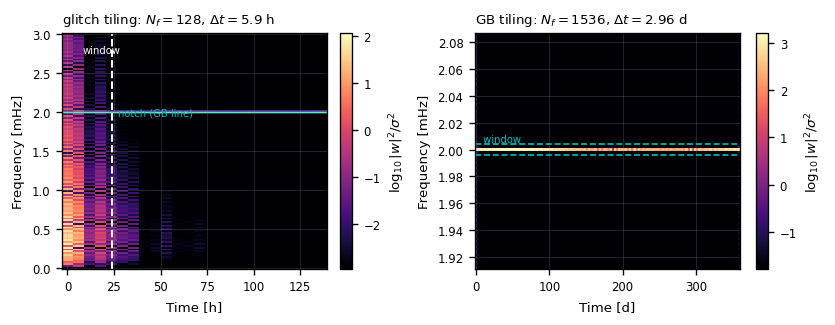

In [19]:
sys.path.insert(0, str(REPO / 'paper' / 'validation'))
from _style import FULL_IN, COL_IN, C, save

# ── the two tilings, both showing the noise-free GB + glitch ────────────────
# The same pair of signals seen through the two tilings: the glitch is a vertical
# band (compact in time, broad in frequency), the GB a horizontal line (compact in
# frequency, present at all times). Each tiling resolves one and smears the other.
h_both = h_gb_fd + h_glitch_fd
w_both_gl = wdm_of(to_time(h_both), NT_GL).coeffs
w_both_gb = wdm_of(to_time(h_both), NT_GB).coeffs

fig, axes = plt.subplots(1, 2, figsize=(FULL_IN, 2.6))

ax, NSHOW = axes[0], 24
P = np.asarray(jnp.nan_to_num(w_both_gl ** 2 / VAR_GL)).sum(axis=0)[:NSHOW]
Q = np.log10(np.maximum(P, 1e-6))
im = ax.pcolormesh(TIME_GL[:NSHOW] / 3600, FREQ_GL * 1e3, Q.T, shading='nearest',
                   cmap='magma', vmin=Q.max() - 5, vmax=Q.max(), rasterized=True)
ax.axhspan(FREQ_GL[max(0, K_GL_NOTCH-HALF_N)] * 1e3,
           FREQ_GL[min(NF_GL, K_GL_NOTCH+HALF_N)] * 1e3, color='c', alpha=0.5, lw=0)
ax.axvline(TIME_GL[NT_WIN] / 3600, color='w', ls='--', lw=1.2)
ax.set_xlabel('Time [h]'); ax.set_ylabel('Frequency [mHz]')
ax.set_title(rf'glitch tiling: $N_f={NF_GL}$, $\Delta t={NF_GL*DT/3600:.1f}$ h',
             fontsize=8, loc='left')
ax.text(TIME_GL[NT_WIN]/3600*0.35, 2.75, 'window', color='w', fontsize=6)
ax.text(TIME_GL[NT_WIN]/3600*1.15, FREQ_GL[K_GL_NOTCH]*1e3, 'notch (GB line)',
        color='c', fontsize=6, va='center')
fig.colorbar(im, ax=ax, label=r'$\log_{10}|w|^2/\sigma^2$')

ax = axes[1]
sl = slice(K_GB - 45, K_GB + 45)
P = np.asarray(jnp.nan_to_num(w_both_gb ** 2 / VAR_GB)).sum(axis=0)[:, sl]
Q = np.log10(np.maximum(P, 1e-6))
im = ax.pcolormesh(TIME_GB / 86400, FREQ_GB[sl] * 1e3, Q.T, shading='nearest',
                   cmap='magma', vmin=Q.max() - 5, vmax=Q.max(), rasterized=True)
ax.axhline(FREQ_GB[GB_CH[0]] * 1e3, color='c', lw=1.0, ls='--')
ax.axhline(FREQ_GB[GB_CH[-1]] * 1e3, color='c', lw=1.0, ls='--')
ax.set_xlabel('Time [d]'); ax.set_ylabel('Frequency [mHz]')
ax.set_title(rf'GB tiling: $N_f={NF_GB}$, $\Delta t={NF_GB*DT/86400:.2f}$ d',
             fontsize=8, loc='left')
ax.text(5, FREQ_GB[GB_CH[-1]]*1e3, ' window', color='c', fontsize=6, va='bottom')
fig.colorbar(im, ax=ax, label=r'$\log_{10}|w|^2/\sigma^2$')
save(fig, 'fig_wdm_tiling'); plt.show()

saved paper/figures/fig_wdm_corner.pdf


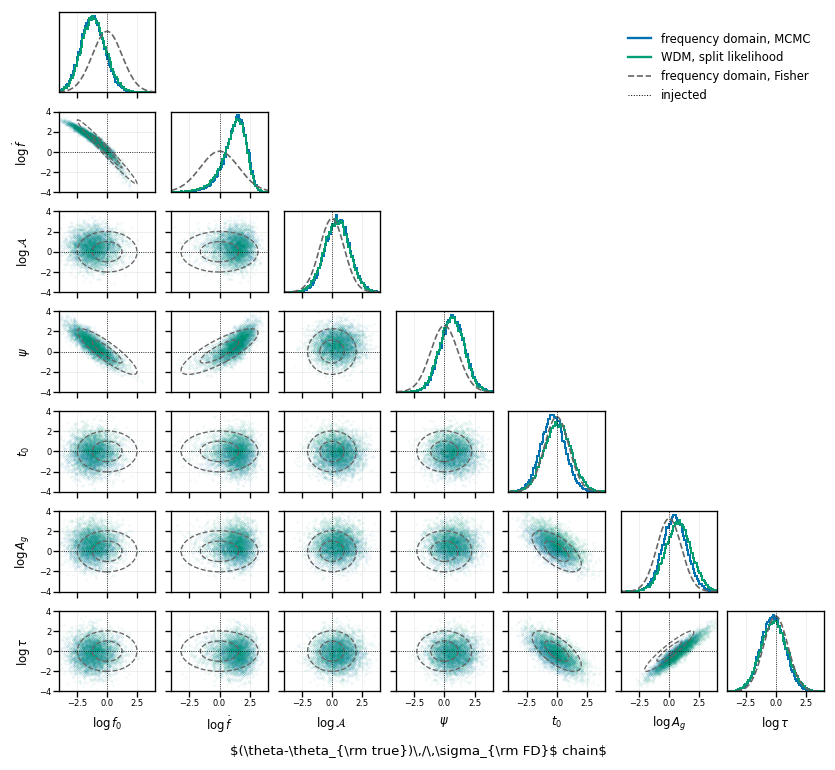

In [20]:
# ── posterior: WDM chain vs frequency-domain Fisher ──────────────────────────
sigR = np.asarray(sig_ref)      # frequency-domain CHAIN width: the robust yardstick
disp = [r'$\log f_0$', r'$\log\dot f$', r'$\log\mathcal{A}$', r'$\psi$',
        r'$t_0$', r'$\log A_g$', r'$\log\tau$']
z = np.asarray((chain - theta_true) / sig_ref)
z_fd = np.asarray((chain_fd - theta_true) / sig_ref)
Cf = np.asarray(-jnp.linalg.inv(H_fd)) / np.outer(sigR, sigR)

def ellipse(ax, C2, i, j, col, ls):
    sub = np.array([[C2[j, j], C2[j, i]], [C2[i, j], C2[i, i]]])
    w_, v_ = np.linalg.eigh(sub); w_ = np.maximum(w_, 0)
    t = np.linspace(0, 2*np.pi, 200)
    for k_ in (1, 2):
        xy = v_ @ (np.sqrt(w_)[:, None] * np.array([np.cos(t), np.sin(t)])) * k_
        ax.plot(xy[0], xy[1], color=col, lw=0.8, ls=ls)

n, LIM = 7, 4.0
fig, axes = plt.subplots(n, n, figsize=(FULL_IN, FULL_IN*0.92))
for r in range(n):
    for c_ in range(n):
        ax = axes[r, c_]
        if c_ > r: ax.set_visible(False); continue
        if r == c_:
            ax.hist(z_fd[:, c_], bins=70, range=(-LIM, LIM), density=True,
                    histtype='step', color=C['blue'], lw=1.2)
            ax.hist(z[:, c_], bins=70, range=(-LIM, LIM), density=True,
                    histtype='step', color=C['green'], lw=1.2)
            g = np.exp(-0.5*np.linspace(-LIM, LIM, 200)**2/Cf[c_, c_])
            ax.plot(np.linspace(-LIM, LIM, 200),
                    g/np.trapezoid(g, np.linspace(-LIM, LIM, 200)),
                    color=C['grey'], lw=1.0, ls='--')
            ax.set_yticks([])
        else:
            for zz, col in ((z_fd, C['blue']), (z, C['green'])):
                k = max(1, len(zz)//2500)
                ax.plot(zz[::k, c_], zz[::k, r], '.', ms=0.4, color=col,
                        alpha=0.16, rasterized=True)
            ellipse(ax, Cf, r, c_, C['grey'], '--')
            ax.axhline(0, color='k', lw=0.5, ls=':'); ax.set_ylim(-LIM, LIM)
        ax.axvline(0, color='k', lw=0.5, ls=':'); ax.set_xlim(-LIM, LIM)
        ax.tick_params(labelsize=5, pad=1)
        if r == n-1: ax.set_xlabel(disp[c_], fontsize=7)
        else: ax.set_xticklabels([])
        if c_ == 0 and r > 0: ax.set_ylabel(disp[r], fontsize=7)
        else: ax.set_yticklabels([])
h = [plt.Line2D([0],[0], color=C['blue'], lw=1.4, label='frequency domain, MCMC'),
     plt.Line2D([0],[0], color=C['green'], lw=1.4, label='WDM, split likelihood'),
     plt.Line2D([0],[0], color=C['grey'], lw=1.0, ls='--', label='frequency domain, Fisher'),
     plt.Line2D([0],[0], color='k', lw=0.6, ls=':', label='injected')]
fig.legend(handles=h, fontsize=7, loc='upper right', bbox_to_anchor=(0.99, 0.98),
           frameon=False)
fig.supxlabel(r'$(\theta-\theta_{\rm true})\,/\,\sigma_{\rm FD}$  (chain width)', fontsize=8)
save(fig, 'fig_wdm_corner'); plt.show()

## 11. Summary

In [21]:
print(f'{"":34s}{"WDM":>12s}{"freq. domain":>14s}')
print(f'{"GB SNR":34s}{np.sqrt(r_gb.sum()):12.2f}{float(jg.snr(h_gb_fd, psd_bin)):14.2f}')
print(f'{"glitch SNR":34s}{np.sqrt(r_gl.sum()):12.2f}{float(jg.snr(h_glitch_fd, psd_bin)):14.2f}')
print(f'{"pixels used":34s}{len(GB_CH)*NT_GB + len(GL_CH)*NT_WIN:12,d}{2*n_fine:14,d}')
print(f'{"cost per likelihood call":34s}{1e3*dt_run/(N_WALKERS*(N_BURN+N_SAMP)):11.2f}ms{"":14s}')
print()
for i, l in enumerate(labels):
    print(f'  sigma[{l:8s}] WDM {float(sig_mc[i]):11.4g}   FD {float(sig_fd[i]):11.4g}'
          f'   ratio {float(sig_mc[i]/sig_fd[i]):6.3f}')

                                           WDM  freq. domain
GB SNR                                  283.47        283.47
glitch SNR                               42.70         42.69
pixels used                              1,106       187,394
cost per likelihood call                 9.30ms              

  sigma[log_f0  ] WDM   1.267e-07   FD   1.531e-07   ratio  0.828
  sigma[log_fdot] WDM      0.2678   FD      0.4008   ratio  0.668
  sigma[log_A_gb] WDM    0.003583   FD    0.003531   ratio  1.015
  sigma[psi     ] WDM    0.003965   FD    0.004464   ratio  0.888
  sigma[t0      ] WDM       7.876   FD       7.209   ratio  1.093
  sigma[log_Ag  ] WDM     0.06809   FD      0.0635   ratio  1.072
  sigma[log_tau ] WDM     0.03366   FD     0.03101   ratio  1.085


In [22]:
# Persist the chain so the figures can be re-made without re-running the sampler.
np.savez_compressed('wdm_chain.npz', chain=np.asarray(chain),
                    chain_fd=np.asarray(chain_fd), sig_ref=np.asarray(sig_ref),
                    theta_true=np.asarray(theta_true),
                    sig_fd=np.asarray(sig_fd), sig_wdm=np.asarray(sig_wdm),
                    H_fd=np.asarray(H_fd), labels=np.array(labels))
print('saved wdm_chain.npz')

saved wdm_chain.npz
